In [1]:
# ============================================================
# Step 1. 데이터 불러오기 + 기본 탐색
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
# 캘리포니아 주택 데이터 불러오기
california = fetch_california_housing(as_frame=True)
df = california.frame

print("데이터 크기:", df.shape)          # (20640, 9)
print("\n상위 5개:\n", df.head())
print("\n결측치 확인:\n", df.isnull().sum())
print("\n기본 통계:\n", df.describe())

데이터 크기: (20640, 9)

상위 5개:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

결측치 확인:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

기본 통계:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean

In [3]:
# ============================================================
# Step 2. 문제지(X)와 정답지(y) 분리
# ============================================================
# X: 집값 예측에 사용할 8개 특성
# y: 예측해야 할 집값 (단위: 10만 달러)

X = df.drop('MedHouseVal', axis=1)   # MedHouseVal 열 제외한 나머지
y = df['MedHouseVal']                # 정답: 집값

print("문제지 크기:", X.shape)   # (20640, 8)
print("정답지 크기:", y.shape)   # (20640,)
print("\n특성 목록:", X.columns.tolist())

문제지 크기: (20640, 8)
정답지 크기: (20640,)

특성 목록: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
# ============================================================
# Step 3. 훈련/테스트 분리
# ============================================================
train_input, test_input, train_target, test_target = train_test_split(
    X, y,
    random_state=42,
    test_size=0.5    # 20%를 테스트로 사용 (데이터가 많으니 20%로)
)

print("훈련 크기:", train_input.shape)   # (16512, 8)
print("테스트 크기:", test_input.shape)  # (4128, 8)

훈련 크기: (10320, 8)
테스트 크기: (10320, 8)


In [6]:
# ============================================================
# Step 4-1. 선형 회귀 (기준점)
# ============================================================
lr = LinearRegression()
lr.fit(train_input, train_target)

print("=== 선형 회귀 (특성 8개) ===")
print("train R²:", lr.score(train_input, train_target))
print("test R²:",  lr.score(test_input, test_target))

# 각 특성의 계수 확인
coef_df = pd.DataFrame({
    '특성': X.columns,
    '계수(w)': lr.coef_
}).sort_values('계수(w)', ascending=False)

print("\n특성별 영향력:")
print(coef_df)
# 계수가 클수록 집값에 큰 영향을 주는 특성

=== 선형 회귀 (특성 8개) ===
train R²: 0.6109210255057085
test R²: 0.5994640188595044

특성별 영향력:
           특성         계수(w)
3   AveBedrms  7.720128e-01
0      MedInc  4.420325e-01
1    HouseAge  9.647486e-03
4  Population -3.566076e-07
5    AveOccup -3.023989e-03
2    AveRooms -1.194035e-01
6    Latitude -4.233425e-01
7   Longitude -4.374872e-01


In [7]:
# ============================================================
# Step 4-2. PolynomialFeatures degree=2
# ============================================================
# 8개 특성 → 제곱항·교차항 추가 → 44개 특성으로 늘어남
# 예: MedInc², MedInc×HouseAge, HouseAge² ...

poly2 = PolynomialFeatures(degree=2, include_bias=False)

# 훈련 데이터로만 fit (Data Leakage 방지)
poly2.fit(train_input)
train_poly2 = poly2.transform(train_input)
test_poly2  = poly2.transform(test_input)   # transform만!

print("degree=2 특성 수:", train_poly2.shape)  # (16512, 44)

lr2 = LinearRegression()
lr2.fit(train_poly2, train_target)

print("\n=== degree=2 (특성 44개) ===")
print("train R²:", lr2.score(train_poly2, train_target))
print("test R²:",  lr2.score(test_poly2, test_target))

degree=2 특성 수: (10320, 44)

=== degree=2 (특성 44개) ===
train R²: 0.6854172826478565
test R²: 0.5219573082629914


In [8]:
# ============================================================
# Step 4-3. 과적합 체험 — degree=3
# ============================================================
# degree=5는 캘리포니아처럼 특성이 많으면 메모리 초과 위험
# degree=3으로도 과적합 충분히 체험 가능

poly3 = PolynomialFeatures(degree=3, include_bias=False)
poly3.fit(train_input)
train_poly3 = poly3.transform(train_input)
test_poly3  = poly3.transform(test_input)

print("degree=3 특성 수:", train_poly3.shape)

lr3 = LinearRegression()
lr3.fit(train_poly3, train_target)

print("\n=== degree=3 결과 ===")
print("train R²:", lr3.score(train_poly3, train_target))
print("test R²:",  lr3.score(test_poly3, test_target))
# train은 높고 test는 낮으면 과적합

degree=3 특성 수: (10320, 164)

=== degree=3 결과 ===
train R²: 0.7352735061830933
test R²: -29.8270828068449


In [9]:
# ============================================================
# Step 5-1. StandardScaler + Ridge
# ============================================================
# degree=2 특성 44개에 Ridge 규제 적용
# 스케일링 필수 → Ridge는 계수 크기에 페널티를 주기 때문

ss = StandardScaler()
train_scaled = ss.fit_transform(train_poly2)   # 훈련만 fit
test_scaled  = ss.transform(test_poly2)        # 테스트는 transform만

# alpha=0.1로 시작
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)

print("=== Ridge (alpha=0.1) ===")
print("train R²:", ridge.score(train_scaled, train_target))
print("test R²:",  ridge.score(test_scaled, test_target))

=== Ridge (alpha=0.1) ===
train R²: 0.6779988015562955
test R²: 0.6369771103943958


c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kim\p1-data\c2_machine_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

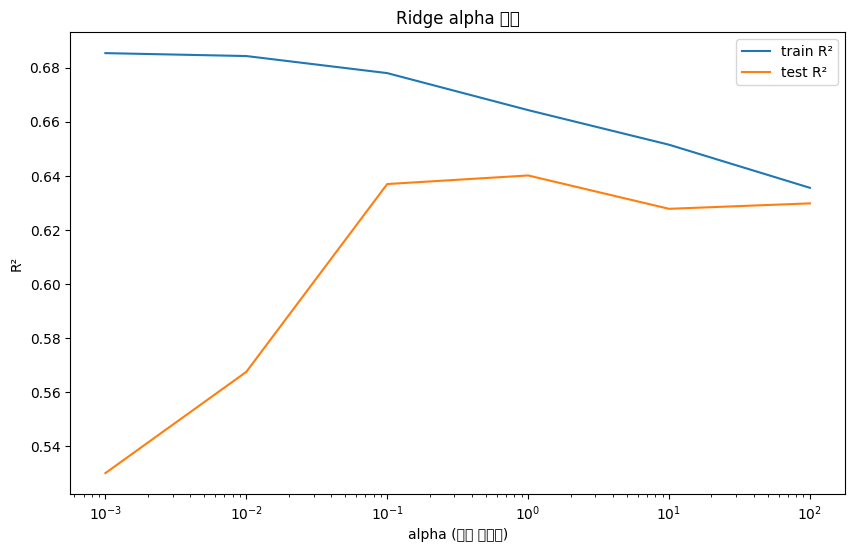

최적 alpha: 100


In [10]:
# ============================================================
# Step 5-2. alpha 탐색 그래프
# ============================================================
train_score, test_score = [], []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plt.figure(figsize=(10, 6))
plt.plot(alpha_list, train_score, label='train R²')
plt.plot(alpha_list, test_score,  label='test R²')
plt.xscale('log')   # x축 로그 스케일 (0.001~100 범위가 넓어서)
plt.xlabel('alpha (로그 스케일)')
plt.ylabel('R²')
plt.title('Ridge alpha 탐색')
plt.legend()
plt.show()

# train/test가 가장 근접한 alpha 출력
best_idx = np.argmin(np.abs(
    np.array(train_score) - np.array(test_score)
))
print(f"최적 alpha: {alpha_list[best_idx]}")

In [11]:
# ============================================================
# Step 5-3. Lasso
# ============================================================
# 44개 특성 중 불필요한 것을 자동으로 0으로 만듦

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(train_scaled, train_target)

print("=== Lasso (alpha=0.01) ===")
print("train R²:", lasso.score(train_scaled, train_target))
print("test R²:",  lasso.score(test_scaled, test_target))
print("0이 된 계수 수:", np.sum(lasso.coef_ == 0))
print("실제 쓰이는 특성 수:", np.sum(lasso.coef_ != 0))

# 살아남은 특성 확인
feature_names = poly2.get_feature_names_out(X.columns)
survived = pd.DataFrame({
    '특성': feature_names,
    '계수': lasso.coef_
})
print("\n살아남은 특성 (계수 ≠ 0):")
print(survived[survived['계수'] != 0].sort_values('계수', ascending=False))

=== Lasso (alpha=0.01) ===
train R²: 0.6114770953612878
test R²: 0.5977975542353964
0이 된 계수 수: 29
실제 쓰이는 특성 수: 15

살아남은 특성 (계수 ≠ 0):
                     특성        계수
9       MedInc HouseAge  0.124192
11     MedInc AveBedrms  0.109723
18   HouseAge AveBedrms  0.078697
12    MedInc Population  0.047082
16           HouseAge^2  0.021174
23           AveRooms^2  0.017247
25  AveRooms Population -0.032803
17    HouseAge AveRooms -0.033026
5              AveOccup -0.038439
8              MedInc^2 -0.052211
33  AveBedrms Longitude -0.098411
2              AveRooms -0.144979
15     MedInc Longitude -0.648685
7             Longitude -0.718849
6              Latitude -0.777536


In [12]:
# ============================================================
# Step 5-4. 전체 결과 비교
# ============================================================
# 최적 alpha로 Ridge 재학습
ridge_best = Ridge(alpha=alpha_list[best_idx])
ridge_best.fit(train_scaled, train_target)

print("=" * 55)
print(f"{'모델':<25} {'train R²':>10} {'test R²':>10}")
print("=" * 55)
print(f"{'선형 회귀 (특성 8개)':<25} {lr.score(train_input, train_target):>10.4f} {lr.score(test_input, test_target):>10.4f}")
print(f"{'다항 회귀 degree=2':<25} {lr2.score(train_poly2, train_target):>10.4f} {lr2.score(test_poly2, test_target):>10.4f}")
print(f"{'다항 회귀 degree=3':<25} {lr3.score(train_poly3, train_target):>10.4f} {lr3.score(test_poly3, test_target):>10.4f}")
print(f"{'Ridge 최적':<25} {ridge_best.score(train_scaled, train_target):>10.4f} {ridge_best.score(test_scaled, test_target):>10.4f}")
print(f"{'Lasso alpha=0.01':<25} {lasso.score(train_scaled, train_target):>10.4f} {lasso.score(test_scaled, test_target):>10.4f}")
print("=" * 55)

모델                          train R²    test R²
선형 회귀 (특성 8개)                 0.6109     0.5995
다항 회귀 degree=2                0.6854     0.5220
다항 회귀 degree=3                0.7353   -29.8271
Ridge 최적                      0.6356     0.6298
Lasso alpha=0.01              0.6115     0.5978
